# **Cardiac Conduction Simulation: A Hybrid Deep Learning Approach to Classify Realistic ECG**

Dataset - (https://www.kaggle.com/datasets/evilspirit05/ecg-analysis/data)

## Dataset Downloading

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d evilspirit05/ecg-analysis

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/evilspirit05/ecg-analysis
License(s): MIT
100% 1.00G/1.00G [00:04<00:00, 244MB/s]



In [3]:
!unzip -q ecg-analysis.zip

In [4]:
import shutil
# shutil.rmtree("ecg data old version")
shutil.rmtree("ecg_data_new_version")

## Data Pre-Processing

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
import seaborn as sns

In [6]:
import shutil
import os

raw_path = "ecg data old version/ecg data old version"
parent_path = "ecg data"

if os.path.exists(parent_path):
    print(f"Destination '{parent_path}' already exists. Removing it before copying.")
    shutil.rmtree(parent_path)

try:
    shutil.copytree(raw_path, parent_path)
    print(f"Successfully copied '{raw_path}' to '{parent_path}'")
except FileNotFoundError:
    print(f"Error: Source directory '{raw_path}' not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully copied 'ecg data old version/ecg data old version' to 'ecg data'


In [11]:
classes = os.listdir(os.path.join(parent_path, "train"))
classes

['ECG Images of Patient that have abnormal heartbeat (233x12=2796)',
 'Normal Person ECG Images (284x12=3408)',
 'ECG Images of Myocardial Infarction Patients (240x12=2880)',
 'ECG Images of Patient that have History of MI (172x12=2064)']

In [12]:
new_class_names = ['Myocardial Infarction', 'History of MI', 'Abnormal Heartbeat', 'Normal']
dirs = ['train', "test"]

for d in dirs:
  folder = os.path.join(parent_path, d)
  for f in range(len(classes)):
    src_path = os.path.join(folder, classes[f])
    dst_path = os.path.join(folder, new_class_names[f])
    os.rename(src_path, dst_path)

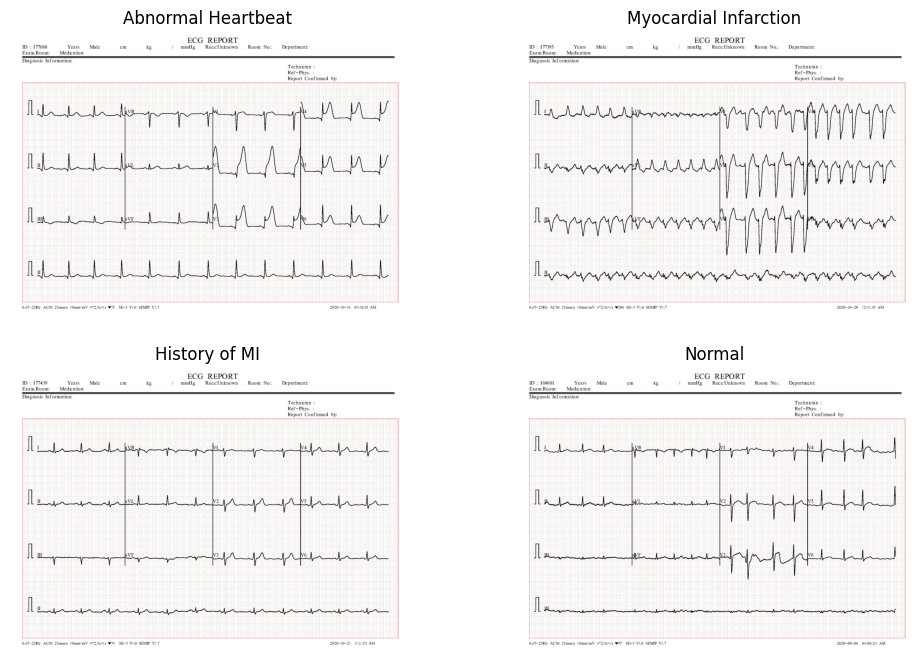

In [13]:
train_path = os.path.join(parent_path, "train")
classes = os.listdir(train_path)

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name) # Fixed: Changed parent_path to train_path

    # get first image from folder
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

## EDA

In [14]:
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name}: {count} images")

Abnormal Heartbeat: 956 images
Myocardial Infarction: 699 images
History of MI: 852 images
Normal: 516 images


In [15]:
train_class_counts = {}

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    train_class_counts[class_name] = len(os.listdir(class_path))

print(train_class_counts)

{'Abnormal Heartbeat': 956, 'Myocardial Infarction': 699, 'History of MI': 852, 'Normal': 516}


In [16]:
test_path = os.path.join(parent_path, "test")
test_class_counts = {}
for class_name in classes:
    class_path = os.path.join(test_path, class_name)
    test_class_counts[class_name] = len(os.listdir(class_path))

print(test_class_counts)

{'Abnormal Heartbeat': 239, 'Myocardial Infarction': 233, 'History of MI': 284, 'Normal': 172}


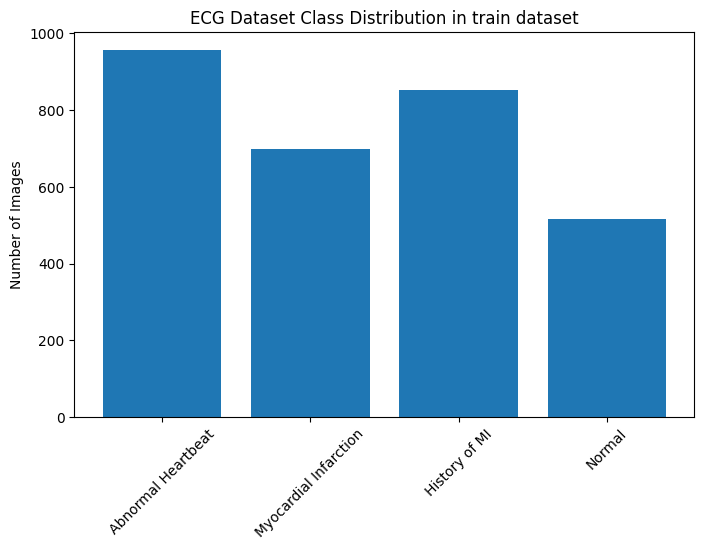

In [17]:
names = list(train_class_counts.keys())
values = list(train_class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("ECG Dataset Class Distribution in train dataset")
plt.ylabel("Number of Images")
plt.show()

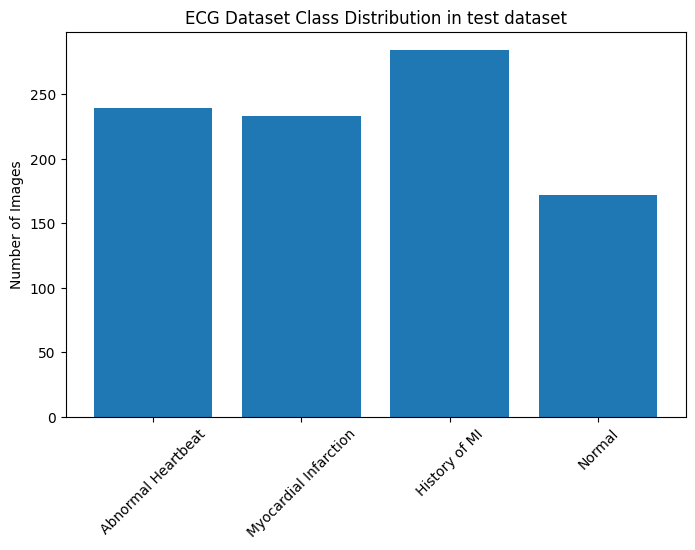

In [18]:
names = list(test_class_counts.keys())
values = list(test_class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("ECG Dataset Class Distribution in test dataset")
plt.ylabel("Number of Images")
plt.show()

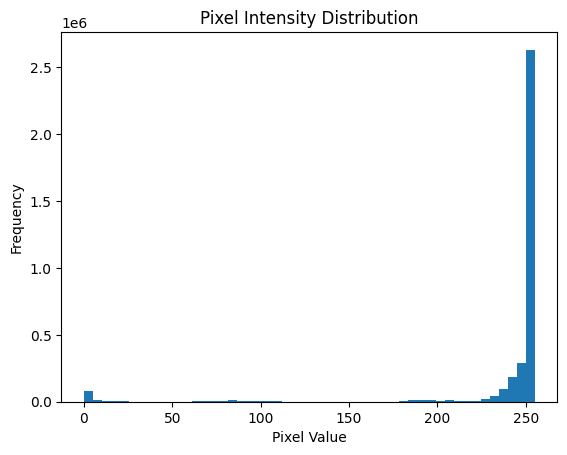

In [19]:
sample_class = classes[0]
sample_path = os.path.join(train_path, sample_class)
img_name = os.listdir(sample_path)[0]

image = cv2.imread(os.path.join(sample_path, img_name), 0)

plt.hist(image.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

### **Edge Detection Analysis**

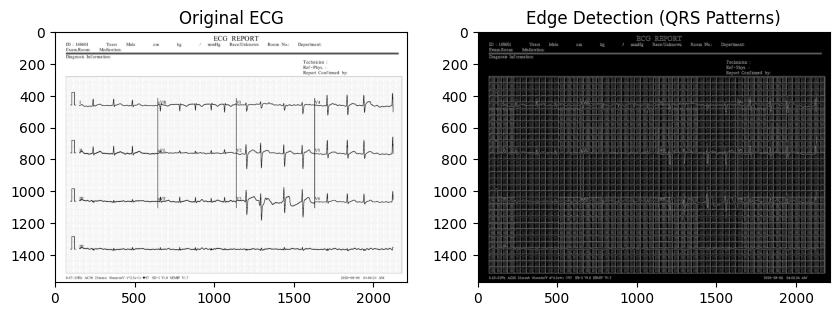

In [20]:
class_name = "Normal"
class_path = os.path.join(train_path, class_name)

img_name = os.listdir(class_path)[0]
img_path = os.path.join(class_path, img_name)

image = cv2.imread(img_path, 0)

edges = cv2.Canny(image, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original ECG")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (QRS Patterns)")

plt.show()

### **ECG Texture Analysis**

In [21]:
from skimage.feature import graycomatrix, graycoprops

image = cv2.imread(img_path, 0)

glcm = graycomatrix(image, [1], [0], 256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

print("Contrast:", contrast)
print("Energy:", energy)
print("Homogeneity:", homogeneity)

Contrast: 1429.6827097396115
Energy: 0.4585773211826015
Homogeneity: 0.5217861416709242


### **Class Distribution Pie Chart**

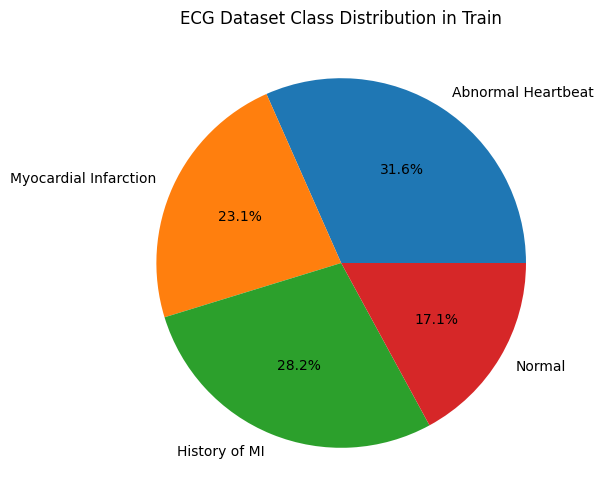

In [22]:
labels = classes
sizes = [len(os.listdir(os.path.join(train_path,c))) for c in classes]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("ECG Dataset Class Distribution in Train")
plt.show()

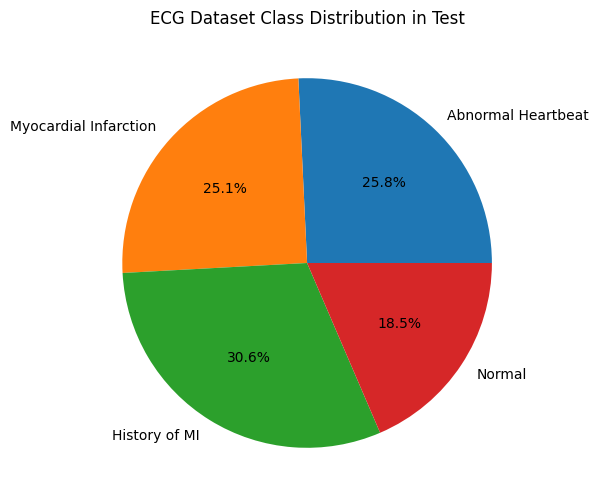

In [23]:
sizes = [len(os.listdir(os.path.join(test_path,c))) for c in classes]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("ECG Dataset Class Distribution in Test")
plt.show()

## Image preprocessing

### **Remove Corrupted Images**

In [24]:
dirs = [train_path, test_path]

invalid_imgs = 0

for d in dirs:
  for class_name in classes:

      class_path = os.path.join(d, class_name)

      for img in os.listdir(class_path):

          img_path = os.path.join(class_path, img)

          image = cv2.imread(img_path)
          if image is None:
              # os.remove(img_path)
              invalid_imgs += 1

print(invalid_imgs)

0


### **Data Augmentation**

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

In [26]:
image_size = (256, 256)
batch_size = 64

train_datagen = ImageDataGenerator(
     rescale=1./255,
     rotation_range=20,
     width_shift_range=0.2,
     height_shift_range=0.2,
     horizontal_flip=True,
     vertical_flip=True,
     validation_split=0.2 # 20% of the training data as validation
)

train_generator = train_datagen.flow_from_directory(
     train_path,
     target_size=image_size,
     batch_size=batch_size,
     class_mode='categorical',
     subset='training'
)

validation_generator = train_datagen.flow_from_directory(
     train_path,
     target_size=image_size,
     batch_size=batch_size,
     class_mode='categorical',
     subset='validation'
)

val_datagen = ImageDataGenerator(rescale=1./255)

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.


In [27]:
test_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 928 images belonging to 4 classes.


In [28]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.7908496732026143), 1: np.float64(0.8870967741935484), 2: np.float64(1.0803571428571428), 3: np.float64(1.4648910411622276)}


## **VGG16 Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze initial layers, unfreeze later layers
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Build enhanced model
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=predictions)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.metrics import F1Score

# Compile with different optimizer settings
vgg_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [ ]:
vgg_history = vgg_model.fit(train_generator, epochs=30, verbose=1,
          validation_data=validation_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 214s 5s/step - accuracy: 0.2950 - f1_score: 0.2894 - loss: 2.0310 - precision: 0.2973 - recall: 0.2174 - val_accuracy: 0.3350 - val_f1_score: 0.2291 - val_loss: 1.3479 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.3674 - f1_score: 0.3596 - loss: 1.7227 - precision: 0.3850 - recall: 0.2884 - val_accuracy: 0.3831 - val_f1_score: 0.2875 - val_loss: 1.2944 - val_precision: 0.7959 - val_recall: 0.0647
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.4281 - f1_score: 0.4151 - loss: 1.4971 - precision: 0.4557 - recall: 0.3508 - val_accuracy: 0.3698 - val_f1_score: 0.2893 - val_loss: 1.2740 - val_precision: 0.6667 - val_recall: 0.1857
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.4541 - f1_score: 0.4390 - loss: 1.4824 - precision: 0.4894 - recall: 0.3897 - val_accuracy: 0.4693 - val_f1_score: 0.4465 - val_loss: 1.1589 - val_precision: 0.6977 - val_rec

## **ResNet50 Model**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

image_size = (224, 224) # ResNet50 expects 224x224 input
batch_size = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2 # Use 20% of the training data for validation
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


test_generator = val_datagen.flow_from_directory(
    test_path,              # Use the correct test data path
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False           # Do not shuffle test data for consistent evaluation
)

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 928 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
callbacks = [early_stop]

# Load ResNet50 base model (pretrained on ImageNet)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze initial layers (transfer learning)
for layer in base_model.layers[:140]:  # freeze first ~140 layers
    layer.trainable = False
for layer in base_model.layers[140:]:
    layer.trainable = True

# Build custom classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

# Train the model
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.2587 - f1_score: 0.2534 - loss: 2.0844 - precision: 0.2647 - recall: 0.1897 - val_accuracy: 0.2322 - val_f1_score: 0.1434 - val_loss: 1.5575 - val_precision: 0.3333 - val_recall: 0.0050
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.2876 - f1_score: 0.2863 - loss: 1.9665 - precision: 0.2892 - recall: 0.2029 - val_accuracy: 0.2819 - val_f1_score: 0.1100 - val_loss: 1.7827 - val_precision: 0.2768 - val_recall: 0.2570
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.2905 - f1_score: 0.2859 - loss: 1.9070 - precision: 0.3027 - recall: 0.2124 - val_accuracy: 0.2803 - val_f1_score: 0.1143 - val_loss: 1.8862 - val_precision: 0.2876 - val_recall: 0.2570
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.3004 - f1_score: 0.2951 - loss: 1.9080 - precision: 0.3216 - recall: 0.2256 - val_accuracy: 0.2803 - val_f1_score: 0.1628 - val_loss: 1.7394 - val_precision: 0.2892 - val_recall: 0.1990

In [ ]:
import matplotlib.pyplot as plt

# Function to plot all models together
def plot_all_models_results(histories, model_names):
    epochs = [range(1, len(h.history['accuracy'])+1) for h in histories]

    plt.figure(figsize=(16, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    for i, h in enumerate(histories):
        plt.plot(epochs[i], h.history['accuracy'], marker='o', label=f'{model_names[i]} Train')
        plt.plot(epochs[i], h.history['val_accuracy'], marker='x', linestyle='--', label=f'{model_names[i]} Val')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    for i, h in enumerate(histories):
        plt.plot(epochs[i], h.history['loss'], marker='o', label=f'{model_names[i]} Train')
        plt.plot(epochs[i], h.history['val_loss'], marker='x', linestyle='--', label=f'{model_names[i]} Val')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

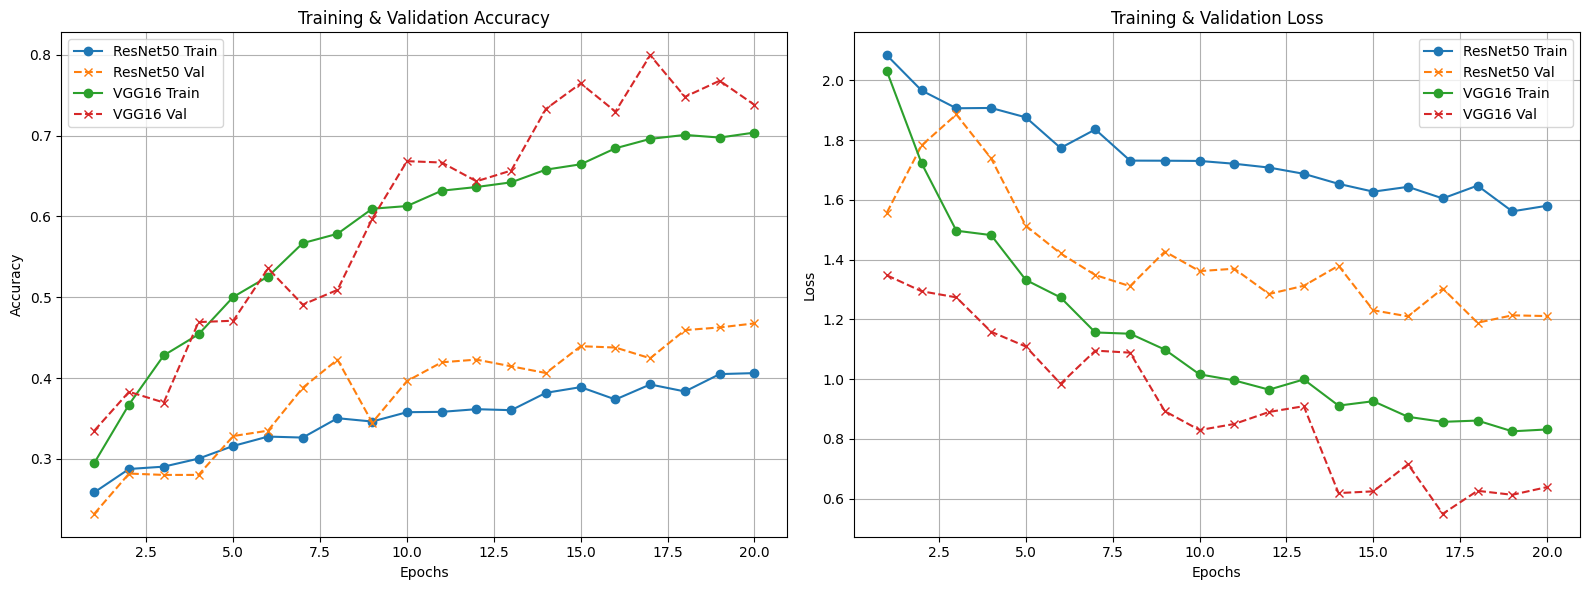

In [ ]:
# List of histories and model names
histories = [history_resnet, vgg_history]
model_names = ["ResNet50", "VGG16"]

# Plot results
plot_all_models_results(histories, model_names)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

vgg_eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2) # Use validation_split to get the same subset

vgg_eval_validation_generator = vgg_eval_datagen.flow_from_directory(
    train_path,
    target_size=(256, 256),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Evaluate ResNet50 (using the current validation_generator from h8Uj3swKXpva, which is 224x224)
resnet_results = resnet_model.evaluate(validation_generator, verbose=0)
resnet_metrics = {
    'loss': resnet_results[0],
    'accuracy': resnet_results[1],
    'precision': resnet_results[2],
    'recall': resnet_results[3],
    'f1_score': resnet_results[4]
}

# Evaluate VGG16 (using the newly created vgg_eval_validation_generator)
vgg_results = vgg_model.evaluate(vgg_eval_validation_generator, verbose=0)
vgg_metrics = {
    'loss': vgg_results[0],
    'accuracy': vgg_results[1],
    'precision': vgg_results[2],
    'recall': vgg_results[3],
    'f1_score': vgg_results[4]
}

# Metrics to visualize
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']

Found 603 images belonging to 4 classes.


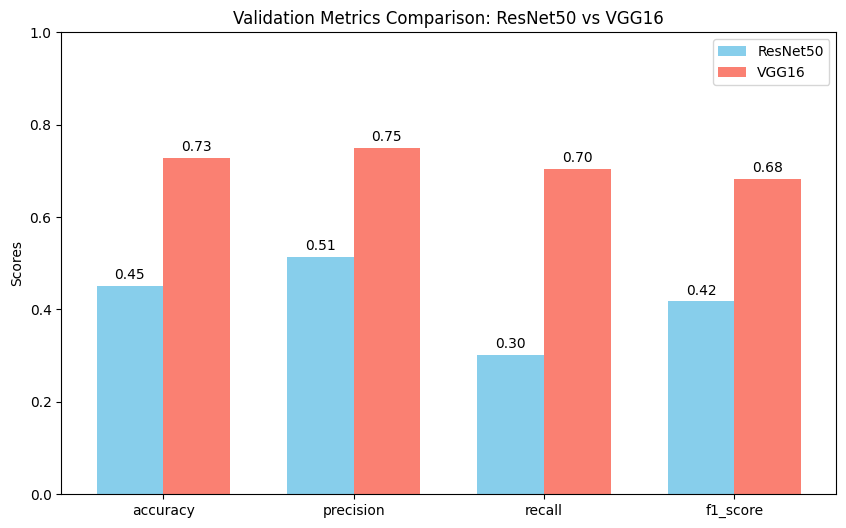

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
resnet_values = [resnet_metrics[m] for m in metrics_to_plot]
vgg_values = [vgg_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, resnet_values, width, label='ResNet50', color='skyblue')
rects2 = ax.bar(x + width/2, vgg_values, width, label='VGG16', color='salmon')

# Add labels
ax.set_ylabel('Scores')
ax.set_title('Validation Metrics Comparison: ResNet50 vs VGG16')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.legend()

# Show values on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()

In [ ]:
import pandas as pd

# Build table
comparison_df = pd.DataFrame({
    "Metric": metrics_to_plot,
    "ResNet50": [resnet_metrics[m] for m in metrics_to_plot],
    "VGG16": [vgg_metrics[m] for m in metrics_to_plot]
})

# Round values for readability
comparison_df = comparison_df.round(4)


In [ ]:
from IPython.display import display
display(comparison_df)

,Metric,ResNet50,VGG16
0,accuracy,0.4511,0.7280
1,precision,0.5142,0.7482
2,recall,0.3002,0.7048
3,f1_score,0.4170,0.6814


# **Finetuned DenseNet121**

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import F1Score

from sklearn.metrics import classification_report, confusion_matrix

In [34]:
train_path = os.path.join(parent_path, "train")
test_path = os.path.join(parent_path, "test")

image_size = (224, 224)
batch_size = 32

In [35]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = val_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 928 images belonging to 4 classes.


In [43]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze initial layers
for layer in base_model.layers[:200]:
    layer.trainable = False
for layer in base_model.layers[200:]:
    layer.trainable = True

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', 'f1_score'] # Removed F1Score for diagnosis
)

In [44]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, lr_scheduler]

In [45]:
densenet_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.4021 - f1_score: 0.3933 - loss: 1.7075 - precision: 0.4334 - recall: 0.3388 - val_accuracy: 0.3350 - val_f1_score: 0.2358 - val_loss: 1.3748 - val_precision: 0.4054 - val_recall: 0.0498 - learning_rate: 1.0000e-04
Epoch 2/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6004 - f1_score: 0.5775 - loss: 1.0818 - precision: 0.6432 - recall: 0.5512 - val_accuracy: 0.5605 - val_f1_score: 0.5250 - val_loss: 0.9366 - val_precision: 0.6313 - val_recall: 0.4345 - learning_rate: 1.0000e-04
Epoch 3/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7095 - f1_score: 0.6828 - loss: 0.7639 - precision: 0.7404 - recall: 0.6822 - val_accuracy: 0.7761 - val_f1_score: 0.7670 - val_loss: 0.5695 - val_precision: 0.8160 - val_recall: 0.7280 - learning_rate: 1.0000e-04
Epoch 4/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.7698 - f1_score: 0.7483 - loss: 0.6482 - precision: 0.7892 - recall: 0.7504 - val_accuracy: 0.8706 -

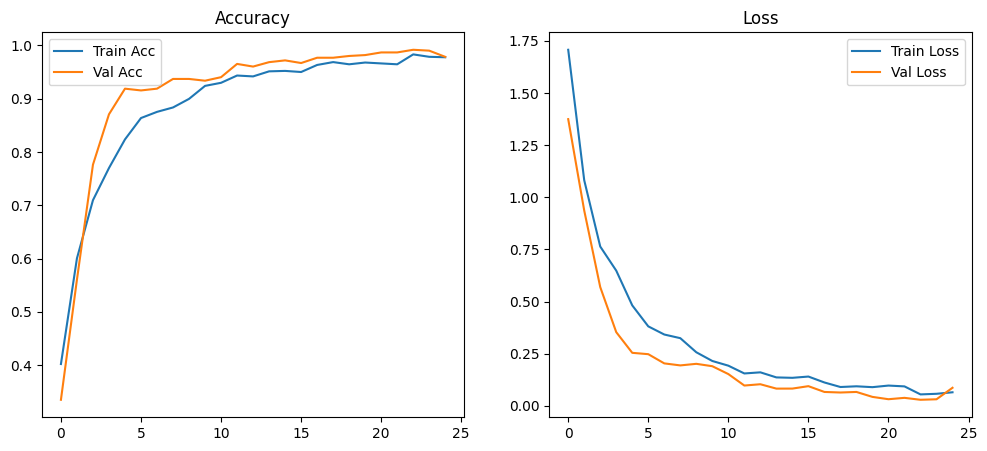

In [46]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(densenet_history.history['accuracy'], label='Train Acc')
plt.plot(densenet_history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(densenet_history.history['loss'], label='Train Loss')
plt.plot(densenet_history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [47]:
test_loss, test_acc, test_prec, test_rec, test_f1 = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Precision:", test_prec)
print("Recall:", test_rec)
print("F1 Score:", test_f1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 770ms/step - accuracy: 0.8804 - f1_score: 0.8740 - loss: 0.3429 - precision: 0.8878 - recall: 0.8782
Test Accuracy: 0.8803879022598267
Precision: 0.8877995610237122
Recall: 0.8782327771186829
F1 Score: [0.9428007  0.91385764 0.82025313 0.8190475 ]


29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 695ms/step
                       precision    recall  f1-score   support

   Abnormal Heartbeat       0.89      1.00      0.94       239
        History of MI       0.98      0.86      0.91       284
Myocardial Infarction       1.00      0.70      0.82       233
               Normal       0.69      1.00      0.82       172

             accuracy                           0.88       928
            macro avg       0.89      0.89      0.87       928
         weighted avg       0.91      0.88      0.88       928



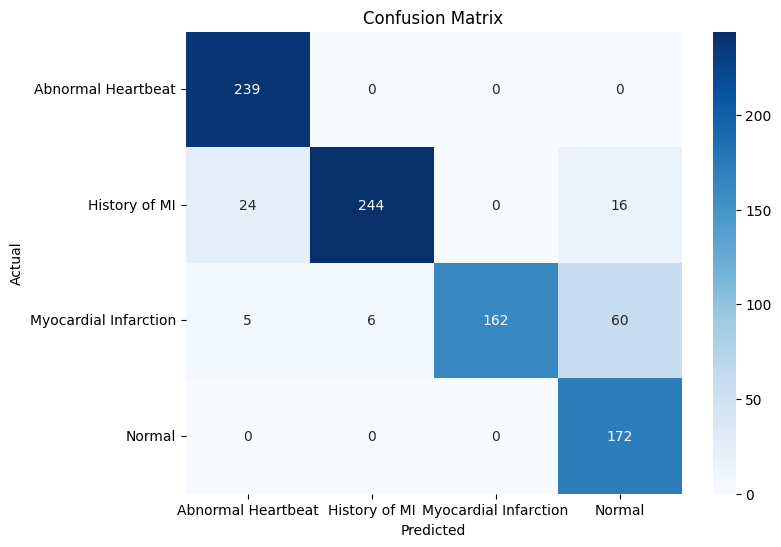

In [48]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

y_pred_labels = [class_labels[i] for i in y_pred_classes]
y_true_labels = [class_labels[i] for i in y_true]

29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 738ms/step


## Test Predictions

In [50]:
for i in range(10):
    print(f"Image {i+1}")
    print("Actual:", y_true_labels[i])
    print("Predicted:", y_pred_labels[i])
    print("-"*30)

Image 1
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 2
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 3
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 4
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 5
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 6
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 7
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 8
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 9
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------
Image 10
Actual: Abnormal Heartbeat
Predicted: Abnormal Heartbeat
------------------------------


29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 758ms/step


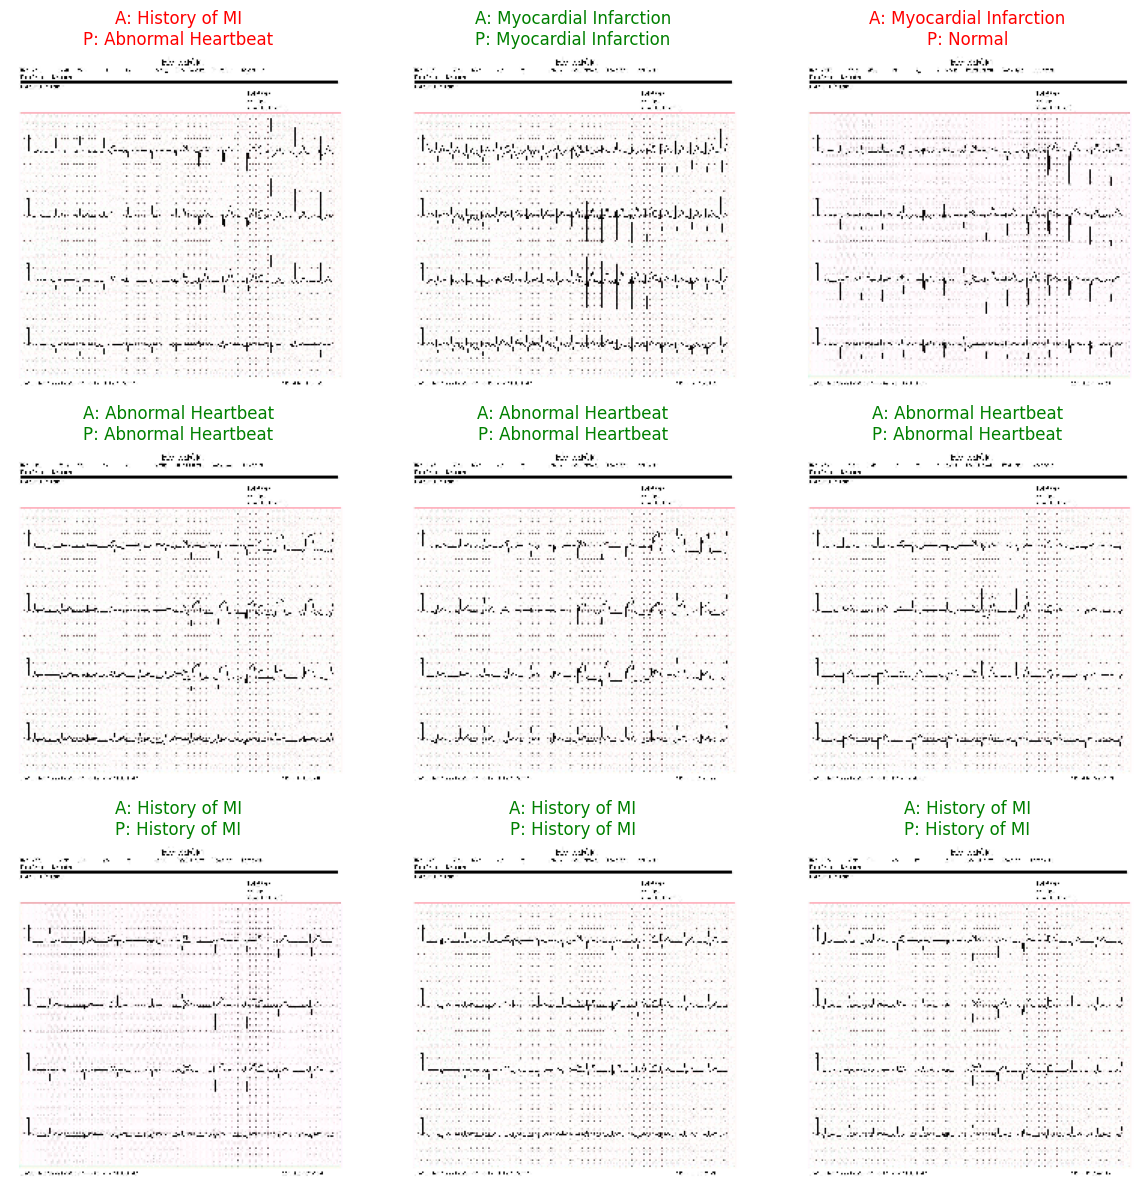

In [52]:
import random
from tensorflow.keras.preprocessing import image

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

y_pred_labels = [class_labels[i] for i in y_pred_classes]
y_true_labels = [class_labels[i] for i in y_true]

plt.figure(figsize=(12,12))

# pick 9 random indices
random_indices = random.sample(range(len(y_true_labels)), 9)

for i, idx in enumerate(random_indices):
    plt.subplot(3,3,i+1)

    img_path = os.path.join(test_path, test_generator.filenames[idx])
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0

    plt.imshow(img_array)

    # color: green if correct, red if wrong
    color = 'green' if y_true_labels[idx] == y_pred_labels[idx] else 'red'

    plt.title(f"A: {y_true_labels[idx]}\nP: {y_pred_labels[idx]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

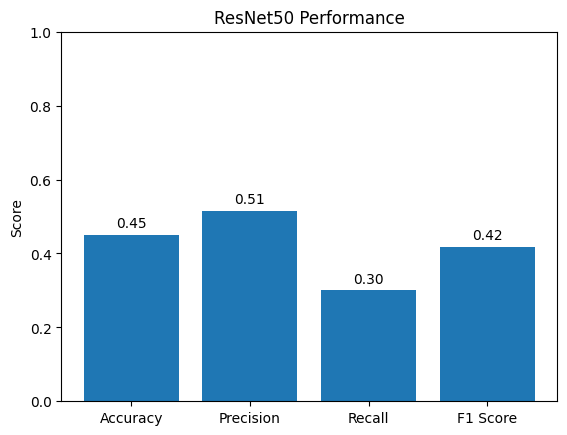

In [55]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
resnet_values = [0.4511, 0.5142, 0.3002, 0.4170]

plt.figure()
bars = plt.bar(metrics, resnet_values)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center')

plt.title("ResNet50 Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

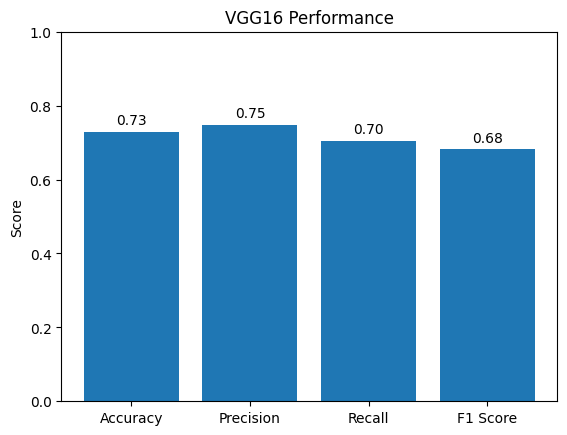

In [56]:
vgg_values = [0.7280, 0.7482, 0.7048, 0.6814]

plt.figure()
bars = plt.bar(metrics, vgg_values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center')

plt.title("VGG16 Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

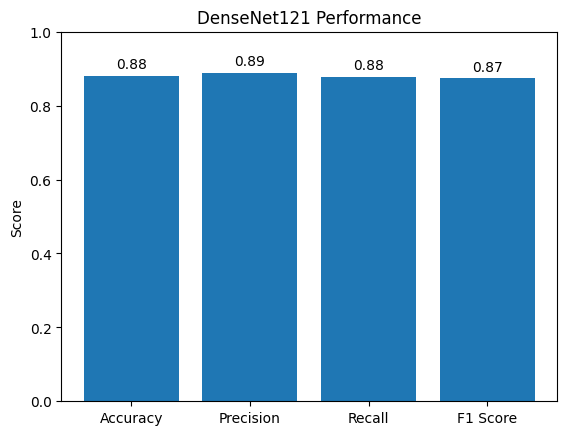

In [58]:
densenet_values = [0.8804, 0.8878, 0.8782, 0.8740]

plt.figure()
bars = plt.bar(metrics, densenet_values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center')

plt.title("DenseNet121 Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

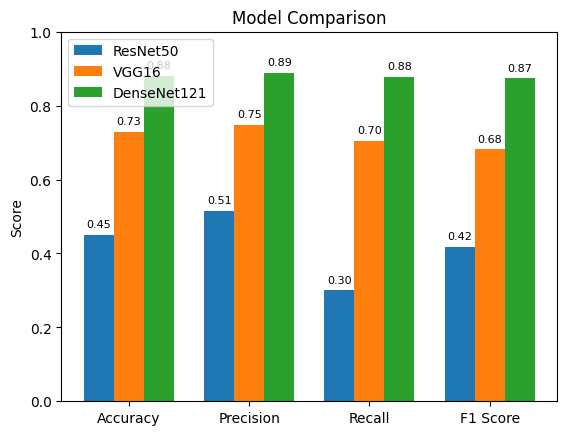

In [59]:
import numpy as np

x = np.arange(len(metrics))
width = 0.25

plt.figure()

bars1 = plt.bar(x - width, resnet_values, width, label='ResNet50')
bars2 = plt.bar(x, vgg_values, width, label='VGG16')
bars3 = plt.bar(x + width, densenet_values, width, label='DenseNet121')

# Add values on each bar
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.ylim(0,1)

plt.show()

In [61]:
import pandas as pd

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Model values
resnet_values = [0.4511, 0.5142, 0.3002, 0.4170]
vgg_values = [0.7280, 0.7482, 0.7048, 0.6814]
densenet_values = [0.8804, 0.8878, 0.8782, 0.8740]

# Create DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics,
    'ResNet50': resnet_values,
    'VGG16': vgg_values,
    'DenseNet121': densenet_values
})

# Round values to 2 decimals
comparison_df = comparison_df.round(2)

# Display table
print(comparison_df)

      Metric  ResNet50  VGG16  DenseNet121
0   Accuracy      0.45   0.73         0.88
1  Precision      0.51   0.75         0.89
2     Recall      0.30   0.70         0.88
3   F1 Score      0.42   0.68         0.87
